In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

import shap
import joblib

sns.set_style("whitegrid")

In [2]:
CONFIG = {
    "data_path": "data/pd_motor_speech_dataset.csv",
    "output_dir": "clinical_scoring_outputs",
    "test_size": 0.2,
    "random_state": 42
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

In [3]:
df = pd.read_csv(CONFIG["data_path"])

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (130, 65)


,Participant code,Age (years),Gender,Positive history of Parkinson disease in family,Age of disease onset (years),Duration of disease from first symptoms (years),Antidepressant therapy,Antiparkinsonian medication,Antipsychotic medication,Benzodiazepine medication,...,Acceleration of speech timing (-/min2) .1,Duration of pause intervals (ms) .1,Duration of voiced intervals (ms) .1,Gaping in-between voiced Intervals (-/min),Duration of unvoiced stops (ms) .1,Decay of unvoiced fricatives (‰/min) .1,Relative loudness of respiration (dB) .1,Pause intervals per respiration (-) .1,Rate of speech respiration (-/min) .1,Latency of respiratory exchange (ms) .1
0,PD01,58,F,No,56,2,No,No,No,No,...,-2.82,158,318,49.01,22.37,0.588,-19.77,6.0,13.81,127
1,PD02,68,F,No,67,1,No,No,No,No,...,8.20,295,264,40.56,26.88,-0.825,-23.26,4.0,21.77,313
2,PD03,68,M,No,67,1,No,No,No,No,...,4.71,280,317,48.97,22.37,-0.955,-13.29,4.0,22.52,201
3,PD04,75,M,No,73,2,No,No,No,No,...,-9.09,397,800,18.69,49.37,0.791,-25.08,2.0,14.37,151
4,PD05,61,M,Yes,60,0.7,No,No,No,No,...,11.77,206,480,33.54,26.87,0.075,-22.32,5.0,14.61,151


In [4]:
df.columns

Index([' Participant  code ', ' Age  (years) ', 'Gender',
       ' Positive  history  of  Parkinson  disease  in  family ',
       ' Age  of  disease  onset  (years) ',
       ' Duration  of  disease  from  first  symptoms  (years) ',
       ' Antidepressant  therapy ', ' Antiparkinsonian  medication ',
       ' Antipsychotic  medication ', ' Benzodiazepine  medication ',
       ' Levodopa  equivalent  (mg/day) ', ' Clonazepam  (mg/day) ',
       ' Overview  of  motor  examination:  Hoehn  &  Yahr  scale  (-) ',
       ' Overview  of  motor  examination:  UPDRS  III  total  (-) ',
       ' 18.  Speech ', ' 19.  Facial  Expression ',
       ' 20.  Tremor  at  Rest  -  head ', ' 20.  Tremor  at  Rest  -  RUE ',
       ' 20.  Tremor  at  Rest  -  LUE ', ' 20.  Tremor  at  Rest  -  RLE ',
       ' 20.  Tremor  at  Rest  -  LLE ',
       ' 21.  Action  or  Postural  Tremor  -  RUE ',
       ' 21.  Action  or  Postural  Tremor  -  LUE ',
       ' 22.  Rigidity  -  neck ', ' 22.  Rigidity  - 

In [5]:
df["group"] = df[' Participant  code '].str.extract(r'([A-Za-z]+)')
print(df["group"].value_counts())

group
RBD    50
HC     50
PD     30
Name: count, dtype: int64


In [6]:
df = df.drop(columns=[' Participant  code '])

In [7]:
df.replace("-", np.nan, inplace=True)

,Age (years),Gender,Positive history of Parkinson disease in family,Age of disease onset (years),Duration of disease from first symptoms (years),Antidepressant therapy,Antiparkinsonian medication,Antipsychotic medication,Benzodiazepine medication,Levodopa equivalent (mg/day),...,Duration of pause intervals (ms) .1,Duration of voiced intervals (ms) .1,Gaping in-between voiced Intervals (-/min),Duration of unvoiced stops (ms) .1,Decay of unvoiced fricatives (‰/min) .1,Relative loudness of respiration (dB) .1,Pause intervals per respiration (-) .1,Rate of speech respiration (-/min) .1,Latency of respiratory exchange (ms) .1,group
0,58,F,No,56,2,No,No,No,No,0,...,158,318,49.01,22.37,0.588,-19.77,6.0,13.81,127,PD
1,68,F,No,67,1,No,No,No,No,0,...,295,264,40.56,26.88,-0.825,-23.26,4.0,21.77,313,PD
2,68,M,No,67,1,No,No,No,No,0,...,280,317,48.97,22.37,-0.955,-13.29,4.0,22.52,201,PD
3,75,M,No,73,2,No,No,No,No,0,...,397,800,18.69,49.37,0.791,-25.08,2.0,14.37,151,PD
4,61,M,Yes,60,0.7,No,No,No,No,0,...,206,480,33.54,26.87,0.075,-22.32,5.0,14.61,151,PD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,69,M,NaN,NaN,NaN,No,No,No,No,0,...,264,380,36.36,26.88,0.023,-23.12,3.0,15.41,177,HC
126,68,M,NaN,NaN,NaN,No,No,No,No,0,...,177,359,47.06,22.37,-0.117,-18.67,5.0,16.94,138,HC
127,53,M,NaN,NaN,NaN,No,No,No,No,0,...,223,391,37.74,40.37,0.411,-15.56,3.0,19.51,156,HC
128,44,M,NaN,NaN,NaN,No,No,No,No,0,...,252,361,38.92,26.88,0.389,-17.53,4.0,17.51,154,HC


In [8]:
def clean_medication(x):
    
    if pd.isna(x):
        return np.nan
        
    x = str(x)
    
    if "Yes" in x:
        return 1
    if "No" in x:
        return 0
        
    return x

for col in df.columns:
    
    if df[col].dtype == "object":
        df[col] = df[col].apply(clean_medication)

In [9]:
df.replace({
    "Yes":1,
    "No":0
}, inplace=True)

,Age (years),Gender,Positive history of Parkinson disease in family,Age of disease onset (years),Duration of disease from first symptoms (years),Antidepressant therapy,Antiparkinsonian medication,Antipsychotic medication,Benzodiazepine medication,Levodopa equivalent (mg/day),...,Duration of pause intervals (ms) .1,Duration of voiced intervals (ms) .1,Gaping in-between voiced Intervals (-/min),Duration of unvoiced stops (ms) .1,Decay of unvoiced fricatives (‰/min) .1,Relative loudness of respiration (dB) .1,Pause intervals per respiration (-) .1,Rate of speech respiration (-/min) .1,Latency of respiratory exchange (ms) .1,group
0,58,F,0,56,2,0,0,0,0,0,...,158,318,49.01,22.37,0.588,-19.77,6.0,13.81,127,PD
1,68,F,0,67,1,0,0,0,0,0,...,295,264,40.56,26.88,-0.825,-23.26,4.0,21.77,313,PD
2,68,M,0,67,1,0,0,0,0,0,...,280,317,48.97,22.37,-0.955,-13.29,4.0,22.52,201,PD
3,75,M,0,73,2,0,0,0,0,0,...,397,800,18.69,49.37,0.791,-25.08,2.0,14.37,151,PD
4,61,M,1,60,0.7,0,0,0,0,0,...,206,480,33.54,26.87,0.075,-22.32,5.0,14.61,151,PD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,69,M,NaN,NaN,NaN,0,0,0,0,0,...,264,380,36.36,26.88,0.023,-23.12,3.0,15.41,177,HC
126,68,M,NaN,NaN,NaN,0,0,0,0,0,...,177,359,47.06,22.37,-0.117,-18.67,5.0,16.94,138,HC
127,53,M,NaN,NaN,NaN,0,0,0,0,0,...,223,391,37.74,40.37,0.411,-15.56,3.0,19.51,156,HC
128,44,M,NaN,NaN,NaN,0,0,0,0,0,...,252,361,38.92,26.88,0.389,-17.53,4.0,17.51,154,HC


In [10]:
df["Gender"] = df["Gender"].map({
    "M":0,
    "F":1
})

In [13]:
for col in df.columns:
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [14]:
df = df.loc[:,~df.columns.duplicated()]

In [15]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [16]:
print("Missing values:", df.isnull().sum().sum())

df.dtypes.value_counts()

Missing values: 130


float64    52
int64      13
Name: count, dtype: int64

In [17]:
df.dtypes[::-1]

group                                                      float64
 Latency  of  respiratory  exchange  (ms) .1                 int64
 Rate  of  speech  respiration  (-/min) .1                 float64
 Pause  intervals  per  respiration  (-) .1                float64
 Relative  loudness  of  respiration  (dB) .1              float64
                                                            ...   
 Duration  of  disease  from  first  symptoms  (years)     float64
 Age  of  disease  onset  (years)                          float64
 Positive  history  of  Parkinson  disease  in  family     float64
Gender                                                       int64
 Age  (years)                                                int64
Length: 65, dtype: object

In [18]:
df.drop('group', axis=1)

,Age (years),Gender,Positive history of Parkinson disease in family,Age of disease onset (years),Duration of disease from first symptoms (years),Antidepressant therapy,Antiparkinsonian medication,Antipsychotic medication,Benzodiazepine medication,Levodopa equivalent (mg/day),...,Acceleration of speech timing (-/min2) .1,Duration of pause intervals (ms) .1,Duration of voiced intervals (ms) .1,Gaping in-between voiced Intervals (-/min),Duration of unvoiced stops (ms) .1,Decay of unvoiced fricatives (‰/min) .1,Relative loudness of respiration (dB) .1,Pause intervals per respiration (-) .1,Rate of speech respiration (-/min) .1,Latency of respiratory exchange (ms) .1
0,58,1,0.0,56.0,2.00,0.0,0,0,0.0,0,...,-2.82,158,318,49.01,22.37,0.588,-19.77,6.0,13.81,127
1,68,1,0.0,67.0,1.00,0.0,0,0,0.0,0,...,8.20,295,264,40.56,26.88,-0.825,-23.26,4.0,21.77,313
2,68,0,0.0,67.0,1.00,0.0,0,0,0.0,0,...,4.71,280,317,48.97,22.37,-0.955,-13.29,4.0,22.52,201
3,75,0,0.0,73.0,2.00,0.0,0,0,0.0,0,...,-9.09,397,800,18.69,49.37,0.791,-25.08,2.0,14.37,151
4,61,0,1.0,60.0,0.70,0.0,0,0,0.0,0,...,11.77,206,480,33.54,26.87,0.075,-22.32,5.0,14.61,151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,69,0,0.0,62.5,2.75,0.0,0,0,0.0,0,...,8.43,264,380,36.36,26.88,0.023,-23.12,3.0,15.41,177
126,68,0,0.0,62.5,2.75,0.0,0,0,0.0,0,...,4.09,177,359,47.06,22.37,-0.117,-18.67,5.0,16.94,138
127,53,0,0.0,62.5,2.75,0.0,0,0,0.0,0,...,5.09,223,391,37.74,40.37,0.411,-15.56,3.0,19.51,156
128,44,0,0.0,62.5,2.75,0.0,0,0,0.0,0,...,2.80,252,361,38.92,26.88,0.389,-17.53,4.0,17.51,154


In [19]:
TARGET = ' Overview  of  motor  examination:  UPDRS  III  total  (-) '

y = df[TARGET]
X = df.drop(columns=[TARGET])

In [20]:
X = X.drop('group', axis=1)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
models = {

    "RandomForest":
        RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=4
        ),

    "Ridge":
        Ridge(alpha=1.0)
}

In [24]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error"
    )

    cv_results[name] = scores.mean()

    print(name, -scores.mean())

RandomForest 1.8943330229691626
XGBoost 1.7344038320723034
Ridge 0.8531972040183243


In [25]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [26]:
preds = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)

print("Test MAE:", mae)

Test MAE: 2.5445701290457943


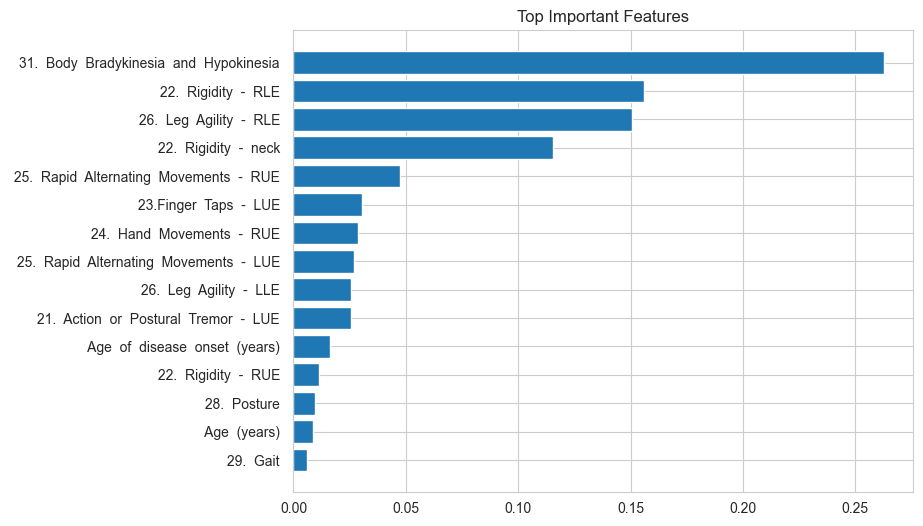

In [27]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8,6))

plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), X.columns[indices])

plt.title("Top Important Features")

plt.show()

In [28]:
import joblib

joblib.dump(model,"updrs_prediction_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']